In [27]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
modeApi = lumapi.MODE(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


GEOMETRIA DO DISPOSITIVO

In [28]:
# Variáveis auxiliares

microns = 1e-6

largura_guia = 0.45 *microns
altura_guia = 0.22 *microns

largura_taper = 1.5*microns
comprimento_taper = 15 *microns

Wm = 7 *microns
We = 7.156 *microns
L = 176 *microns

comprimento_porta = 2 *microns

In [30]:
def geometria_MMI():
    # Caixa central

    modeApi.addrect()
    modeApi.set("name", "Caixa central")
    modeApi.set("x span", L)
    modeApi.set("y span", Wm)
    modeApi.set("z span", altura_guia)
    modeApi.set("x", 0)
    modeApi.set("y", 0)
    modeApi.set("z", 0)
    modeApi.set("material", "Si (Silicon) - Palik")

    # Tapers

    modeApi.addobject("linear_taper")
    modeApi.set("name", "taper1")
    modeApi.set("thickness", altura_guia)
    modeApi.set("width_l", largura_guia)
    modeApi.set("width_r", largura_taper)
    modeApi.set("len", comprimento_taper)
    modeApi.set("x", -(L/2 + comprimento_taper/2))
    modeApi.set("y", We/6)
    modeApi.set("z", 0)
    modeApi.set("angle_side", 90)
    modeApi.set("material", "Si (Silicon) - Palik")

    modeApi.addobject("linear_taper")
    modeApi.set("name", "taper2")
    modeApi.set("thickness", altura_guia)
    modeApi.set("width_l", largura_guia)
    modeApi.set("width_r", largura_taper)
    modeApi.set("len", comprimento_taper)
    modeApi.set("x", -(L/2 + comprimento_taper/2))
    modeApi.set("y", -We/6)
    modeApi.set("z", 0)
    modeApi.set("angle_side", 90)
    modeApi.set("material", "Si (Silicon) - Palik")

    modeApi.addobject("linear_taper")
    modeApi.set("name", "taper3")
    modeApi.set("thickness", altura_guia)
    modeApi.set("width_l", largura_taper)
    modeApi.set("width_r", largura_guia)
    modeApi.set("len", comprimento_taper)
    modeApi.set("x", L/2 + comprimento_taper/2)
    modeApi.set("y", We/6)
    modeApi.set("z", 0)
    modeApi.set("angle_side", 90)
    modeApi.set("material", "Si (Silicon) - Palik")

    modeApi.addobject("linear_taper")
    modeApi.set("name", "taper4")
    modeApi.set("thickness", altura_guia)
    modeApi.set("width_l", largura_taper)
    modeApi.set("width_r", largura_guia)
    modeApi.set("len", comprimento_taper)
    modeApi.set("x", L/2 + comprimento_taper/2)
    modeApi.set("y", -We/6)
    modeApi.set("z", 0)
    modeApi.set("angle_side", 90)
    modeApi.set("material", "Si (Silicon) - Palik")

    # Guias Retos

    modeApi.addrect()
    modeApi.set("name", "porta1")
    modeApi.set("x span", comprimento_porta)
    modeApi.set("y span", largura_guia)
    modeApi.set("z span", altura_guia)
    modeApi.set("x", -(L/2 + comprimento_taper + comprimento_porta/2))
    modeApi.set("y", We/6)
    modeApi.set("z", 0)
    modeApi.set("material", "Si (Silicon) - Palik")

    modeApi.addrect()
    modeApi.set("name", "porta2")
    modeApi.set("x span", comprimento_porta)
    modeApi.set("y span", largura_guia)
    modeApi.set("z span", altura_guia)
    modeApi.set("x", -(L/2 + comprimento_taper + comprimento_porta/2))
    modeApi.set("y", -We/6)
    modeApi.set("z", 0)
    modeApi.set("material", "Si (Silicon) - Palik")

    modeApi.addrect()
    modeApi.set("name", "porta3")
    modeApi.set("x span", comprimento_porta)
    modeApi.set("y span", largura_guia)
    modeApi.set("z span", altura_guia)
    modeApi.set("x", L/2 + comprimento_taper + comprimento_porta/2)
    modeApi.set("y", We/6)
    modeApi.set("z", 0)
    modeApi.set("material", "Si (Silicon) - Palik")

    modeApi.addrect()
    modeApi.set("name", "porta4")
    modeApi.set("x span", comprimento_porta)
    modeApi.set("y span", largura_guia)
    modeApi.set("z span", altura_guia)
    modeApi.set("x", L/2 + comprimento_taper + comprimento_porta/2)
    modeApi.set("y", -We/6)
    modeApi.set("z", 0)
    modeApi.set("material", "Si (Silicon) - Palik")

REGIÃO DE SIMULAÇÃO

In [31]:
# Margem na região de simulação
x_offset = 0.5 *microns
y_offset = 2 *microns
z_offset = 0.5 *microns

In [34]:
def regiao_simulacao(m):
    # Adicionando solver

    modeApi.addvarfdtd()
    modeApi.set("x", 0) # X = Xspan do dispositivo /2
    modeApi.set("y", 0) # O centro é em y = radius
    modeApi.set("z", 0)
    modeApi.set("x span", L + 2*comprimento_taper + comprimento_porta)
    modeApi.set("y span", Wm + 2*y_offset)
    modeApi.set("z span", altura_guia + 2*z_offset)

    modeApi.set("x0", -3 *microns)
    modeApi.set("background material", "SiO2 (Glass) - Palik")
    modeApi.set("global monitor frequency points", 21)
    modeApi.set("mesh accuracy", 5)
    modeApi.set('bandwidth', 'broadband')
    modeApi.set('fit tolerance', 1e-2)
    modeApi.set('simulation time', 3.5 * (10**(-12)))

    modeApi.set('x0', -85*microns)
    modeApi.set('y0', We/6)

    test_points = np.array([[-85*microns, 4.5 *microns],
                            [-85*microns,-4.5 *microns],
                            [ 85*microns, We/6],
                            [ 85*microns, -We/6]])

    modeApi.set('test points', test_points)

    modeApi.set('z max bc', 'PML')
    if m == 0:    # modo TE
        modeApi.set('z min bc', 'Symmetric')
    if m == 1:    # modo TM
        modeApi.set('z min bc', 'Anti-Symmetric')
        modeApi.set('polarization', 'H mode (TM)')

    # Adicionando fonte

    modeApi.addmodesource()
    modeApi.set('injection axis', 'x')
    modeApi.set('mode selection', 'fundamental mode')
    modeApi.set('x', -(L/2 + comprimento_taper + comprimento_porta/4) )
    modeApi.set('y', We/6)
    modeApi.set('y span', 3*microns)
    modeApi.set('wavelength start', 1.5 *microns)
    modeApi.set('wavelength stop', 1.6 *microns)

    modeApi.addpower()
    modeApi.set('name', 'port_1')
    modeApi.set('monitor type', 5)
    modeApi.set('x', -(L/2 + comprimento_taper + comprimento_porta/4) + 0.1 *microns)
    modeApi.set('y', We/6)
    modeApi.set('z', 0)
    modeApi.set('y span', 2*microns)
    modeApi.set('z span', 2*microns)

    modeApi.addpower()
    modeApi.set('name', 'port_2')
    modeApi.set('monitor type', 5)
    modeApi.set('x', -(L/2 + comprimento_taper + comprimento_porta/4) + 0.1 *microns)
    modeApi.set('y', -We/6)
    modeApi.set('z', 0)
    modeApi.set('y span', 2*microns)
    modeApi.set('z span', 2*microns)

    modeApi.addpower()
    modeApi.set('name', 'port_3')
    modeApi.set('monitor type', 5)
    modeApi.set('x', L/2 + comprimento_taper + comprimento_porta/4)
    modeApi.set('y', We/6)
    modeApi.set('z', 0)
    modeApi.set('y span', 2*microns)
    modeApi.set('z span', 2*microns)

    modeApi.addpower()
    modeApi.set('name', 'port_4')
    modeApi.set('monitor type', 5)
    modeApi.set('x', L/2 + comprimento_taper + comprimento_porta/4)
    modeApi.set('y', -We/6)
    modeApi.set('z', 0)
    modeApi.set('y span', 2*microns)
    modeApi.set('z span', 2*microns)

    modeApi.addprofile()
    modeApi.set('name', 'profile')
    modeApi.set('x', 0)
    modeApi.set('y', 0)
    modeApi.set('x span', L + 2*comprimento_taper + comprimento_porta)
    modeApi.set('y span', Wm + 2*y_offset)

SIMULAÇÃO TE

In [ ]:
geometria_MMI
regiao_simulacao(0)
modeApi.save('MMI_varFDTD')
modeApi.run()

In [8]:
eField = np.abs(np.squeeze(modeApi.getelectric('profile')))

x_efield = modeApi.getdata('profile', 'x')
y_efield = modeApi.getdata('profile', 'y')
wavelength_array = nu2lambda(modeApi.getdata('profile', 'f'))
xmin = np.min(x_efield) / microns
xmax = np.max(x_efield) / microns
ymin = np.min(y_efield) / microns
ymax = np.max(y_efield) / microns

central_wavelength_index = np.argmin(np.abs(wavelength_array[:,0] - 1.55*microns))

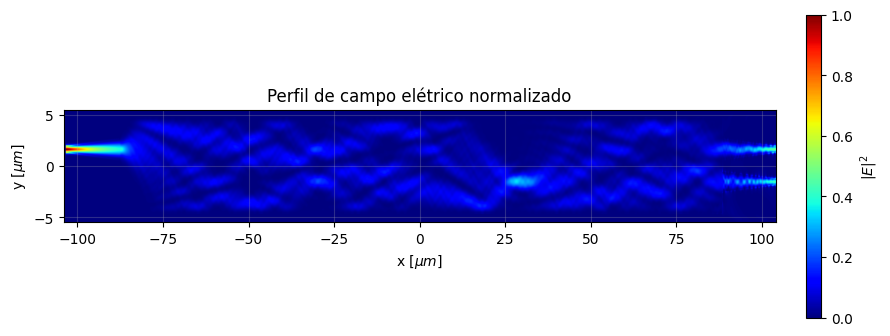

In [32]:
# Escala linear
eField_normalized = eField[:,:,central_wavelength_index]/np.max(eField[:,:,central_wavelength_index])

fig = plt.figure(figsize = (9, 6))
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField_normalized), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title('Perfil de campo elétrico normalizado')
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

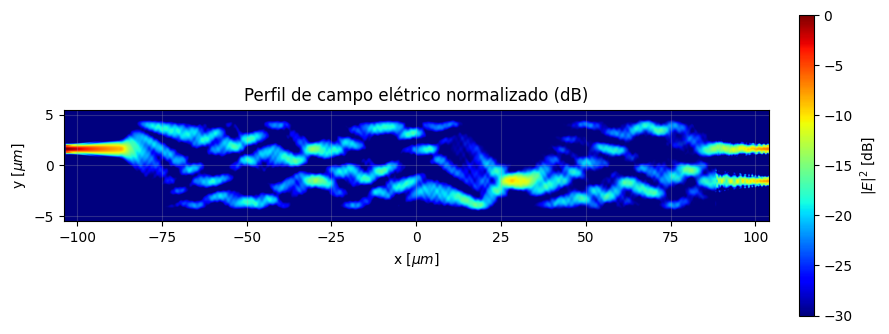

In [33]:
eField2 = np.power(eField,2)

eField2_normalized = eField2[:,:,central_wavelength_index]/np.max(eField2[:,:,central_wavelength_index])

eField2_dB = 10*np.log10(eField2_normalized)

fig = plt.figure(figsize = (9, 6))
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField2_dB), extent=[xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$ [dB]')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title('Perfil de campo elétrico normalizado (dB)')
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_31032\1998578945.py:14: RuntimeWarning: invalid value encountered in log10
  ax[1].plot(lamb[i-1]/microns, 10*np.log10(transmissao[i-1]), label = 'Porta %d' %i, linewidth = 1.5)


Text(0.5, 1.0, 'Transmissão [$dB$] x Comprimento de Onda')

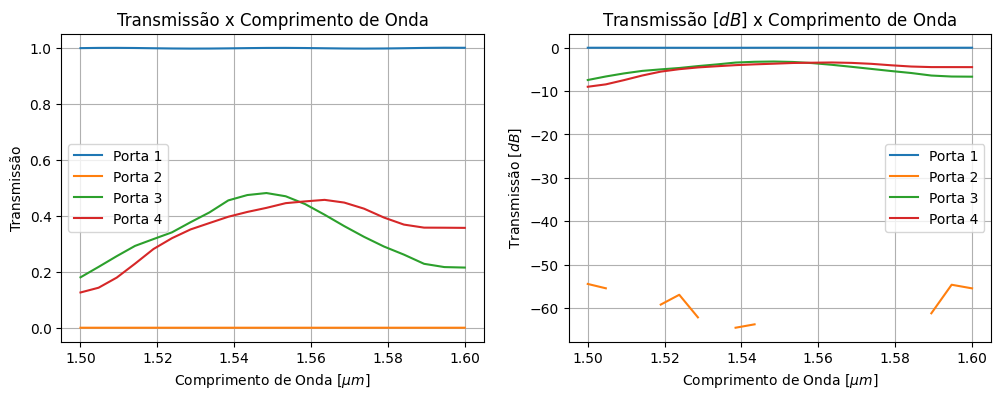

In [22]:
transmissao = [[], [], [], []]

lamb = [[], [], [], []]

#Transmissão do dispositivo em cada porta
fig, ax = plt.subplots(1,2, figsize=(12,4))

for i in range(1,5,1):
    ports = modeApi.getresult('port_%d' %i, 'T')
    transmissao[i-1] = ports['T']
    lamb[i-1] = ports['lambda']

    ax[0].plot(lamb[i-1]/microns, transmissao[i-1], label = 'Porta %d' %i, linewidth = 1.5)
    ax[1].plot(lamb[i-1]/microns, 10*np.log10(transmissao[i-1]), label = 'Porta %d' %i, linewidth = 1.5)

ax[0].grid(True)
ax[0].legend(loc = 'best')
ax[0].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão')
ax[0].set_title(r'Transmissão x Comprimento de Onda')

ax[1].grid(True)
ax[1].legend(loc = 'best')
ax[1].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão [$dB$]')
ax[1].set_title(r'Transmissão [$dB$] x Comprimento de Onda')

C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_31032\3964429469.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_31032\3964429469.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


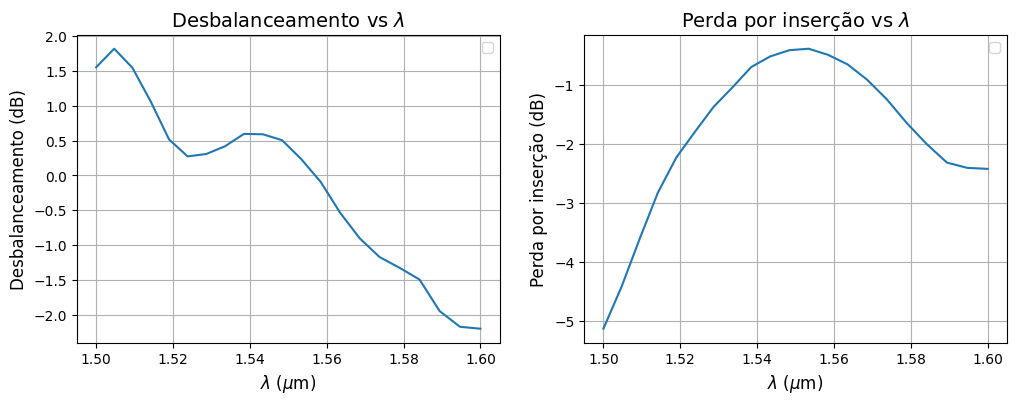

In [27]:
fig, axs = plt.subplots(1,2, figsize = (12,4))

# Imbalance

Ib = 10*np.log10(transmissao[2]) - 10*np.log10(transmissao[3])

axs[0].plot(lamb[2]/microns, Ib, lw = 1.5)
axs[0].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[0].set_ylabel("Desbalanceamento (dB)", fontsize = 12)
axs[0].set_title(r'Desbalanceamento vs $\lambda$', fontsize = 14)
axs[0].grid()
axs[0].legend()


# Insertion Loss

Il = 10*np.log10(transmissao[2] + transmissao[3])

axs[1].plot(lamb[2]/microns, Il, lw = 1.5)
axs[1].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[1].set_ylabel("Perda por inserção (dB)", fontsize = 12)
axs[1].set_title(r'Perda por inserção vs $\lambda$', fontsize = 14)
axs[1].grid()
axs[1].legend()

SIMULAÇÃO MODO TM

In [35]:
geometria_MMI()
regiao_simulacao(1)
modeApi.save('MMI_varFDTD')

In [36]:
modeApi.run()

In [37]:
eField = np.abs(np.squeeze(modeApi.getelectric('profile')))

x_efield = modeApi.getdata('profile', 'x')
y_efield = modeApi.getdata('profile', 'y')
wavelength_array = nu2lambda(modeApi.getdata('profile', 'f'))
xmin = np.min(x_efield) / microns
xmax = np.max(x_efield) / microns
ymin = np.min(y_efield) / microns
ymax = np.max(y_efield) / microns

central_wavelength_index = np.argmin(np.abs(wavelength_array[:,0] - 1.55*microns))

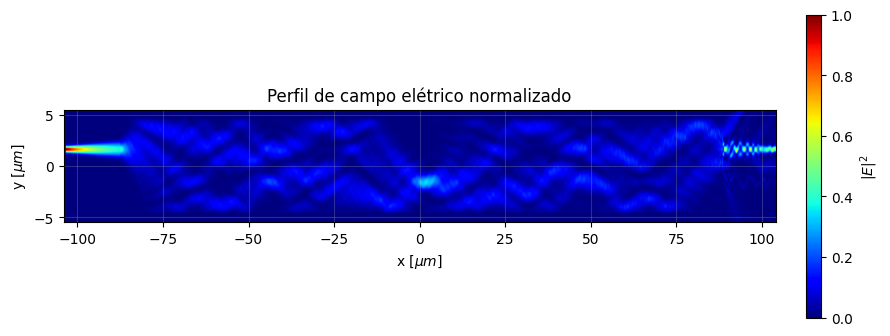

In [38]:
# Escala linear
eField_normalized = eField[:,:,central_wavelength_index]/np.max(eField[:,:,central_wavelength_index])

fig = plt.figure(figsize = (9, 6))
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField_normalized), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title('Perfil de campo elétrico normalizado')
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

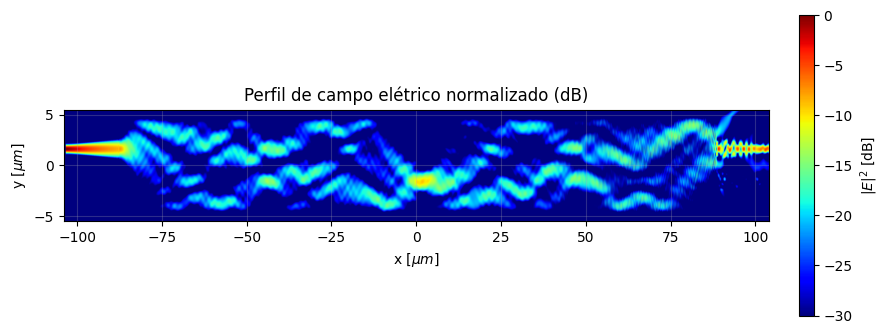

In [40]:
# Escala log
eField2 = np.power(eField,2)

eField2_normalized = eField2[:,:,central_wavelength_index]/np.max(eField2[:,:,central_wavelength_index])

eField2_dB = 10*np.log10(eField2_normalized)

fig = plt.figure(figsize = (9, 6))
ax = fig.add_subplot(111)
im = ax.imshow(np.rot90(eField2_dB), extent=[xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = plt.get_cmap('jet'))

colorbar = plt.colorbar(im,fraction = 0.02, pad =0.04, label = r'$|E|^2$ [dB]')

ax.set_xlabel(r'x [$\mu m$]')
ax.set_ylabel(r'y [$\mu m$]')

ax.set_title('Perfil de campo elétrico normalizado (dB)')
ax.grid(which='major', alpha = 0.25)
ax.set_aspect(3)

plt.tight_layout()
plt.show()

C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_22828\1998578945.py:14: RuntimeWarning: invalid value encountered in log10
  ax[1].plot(lamb[i-1]/microns, 10*np.log10(transmissao[i-1]), label = 'Porta %d' %i, linewidth = 1.5)


Text(0.5, 1.0, 'Transmissão [$dB$] x Comprimento de Onda')

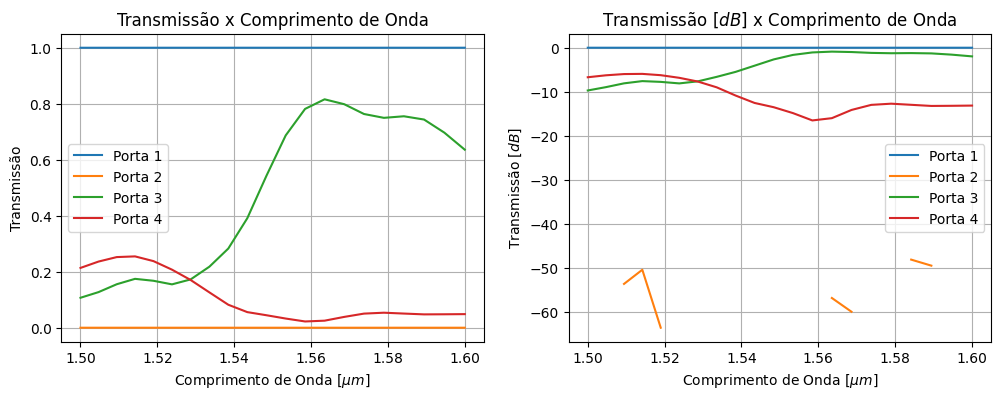

In [41]:
transmissao = [[], [], [], []]

lamb = [[], [], [], []]

#Transmissão do dispositivo em cada porta
fig, ax = plt.subplots(1,2, figsize=(12,4))

for i in range(1,5,1):
    ports = modeApi.getresult('port_%d' %i, 'T')
    transmissao[i-1] = ports['T']
    lamb[i-1] = ports['lambda']

    ax[0].plot(lamb[i-1]/microns, transmissao[i-1], label = 'Porta %d' %i, linewidth = 1.5)
    ax[1].plot(lamb[i-1]/microns, 10*np.log10(transmissao[i-1]), label = 'Porta %d' %i, linewidth = 1.5)

ax[0].grid(True)
ax[0].legend(loc = 'best')
ax[0].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[0].set_ylabel(r'Transmissão')
ax[0].set_title(r'Transmissão x Comprimento de Onda')

ax[1].grid(True)
ax[1].legend(loc = 'best')
ax[1].set_xlabel(r'Comprimento de Onda [$\mu m$]')
ax[1].set_ylabel(r'Transmissão [$dB$]')
ax[1].set_title(r'Transmissão [$dB$] x Comprimento de Onda')

C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_22828\3964429469.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_22828\3964429469.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


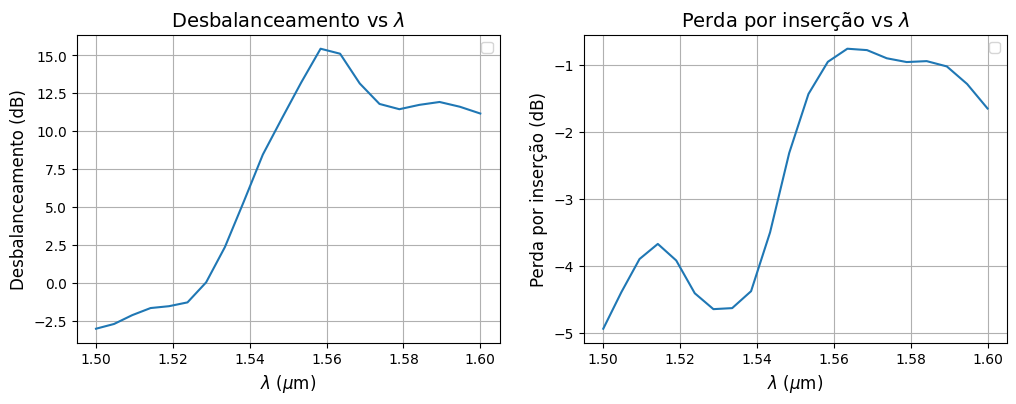

In [42]:
fig, axs = plt.subplots(1,2, figsize = (12,4))

# Imbalance

Ib = 10*np.log10(transmissao[2]) - 10*np.log10(transmissao[3])

axs[0].plot(lamb[2]/microns, Ib, lw = 1.5)
axs[0].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[0].set_ylabel("Desbalanceamento (dB)", fontsize = 12)
axs[0].set_title(r'Desbalanceamento vs $\lambda$', fontsize = 14)
axs[0].grid()
axs[0].legend()


# Insertion Loss

Il = 10*np.log10(transmissao[2] + transmissao[3])

axs[1].plot(lamb[2]/microns, Il, lw = 1.5)
axs[1].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[1].set_ylabel("Perda por inserção (dB)", fontsize = 12)
axs[1].set_title(r'Perda por inserção vs $\lambda$', fontsize = 14)
axs[1].grid()
axs[1].legend()